<a href="https://colab.research.google.com/github/MMujtabaX/Top2Vec/blob/main/Top2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic Modeling & Semantic Search with Top2Vec

**Top2Vec** discovers topics automatically, with no need to choose the number of topics in advance. It works in four steps:

1. **Embed** every document (and word) into the same vector space with a pretrained sentence-transformer
2. **Reduce** the embeddings to a few dimensions with **UMAP**
3. **Cluster** dense regions of documents with **HDBSCAN**. Each dense cluster is a topic.
4. **Describe** each topic by the words whose vectors sit closest to the cluster's centroid

Because documents, words and topics share one vector space, the same model also supports **semantic search**: find topics, documents or similar words for any free-text query.

Dataset: **20 Newsgroups**, about 18,800 Usenet posts from 1993 across 20 discussion groups, with headers, footers and quoted replies removed.

In [ ]:
# !pip install top2vec
# !pip install top2vec[sentence_encoders]
!pip install top2vec[sentence_transformers]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 77.3 MB/s eta 0:00:00


In [ ]:
from top2vec import Top2Vec
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

In [ ]:
for i in range(15):
  print(newsgroups.data[i])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenheit 1280

  - ATI Graphics Ultra Pro

  - Any other high-performance VLB card


Please 

## 1. Training the model

`speed="fast-learn"` trades a little quality for speed. On a Colab CPU, training takes a few minutes: embedding the documents, then UMAP, HDBSCAN and topic extraction.

In [ ]:
model = Top2Vec(documents=newsgroups.data, speed="fast-learn", workers=8)

2026-10-03 10:18:42,956 - top2vec - INFO - Pre-processing documents for training
2026-10-03 10:19:00,114 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
2026-10-03 10:19:09,896 - top2vec - INFO - Creating joint document/word embedding
2026-10-03 10:20:08,487 - top2vec - INFO - Creating lower dimension embedding of documents
2026-10-03 10:20:44,091 - top2vec - INFO - Finding dense areas of documents
2026-10-03 10:20:50,303 - top2vec - INFO - Finding topics


In [ ]:
model.save("our_vector_model")

## 2. How many topics did it find?

In [ ]:
model.get_num_topics()

127

Top2Vec found **127 topics**, far more fine-grained than the 20 newsgroup labels. A single newsgroup like `sci.med` can split into several topics (diagnosis, treatments, nutrition...), and some topics cut across groups.

## 3. Searching topics by keyword

Find the topics whose vectors are closest to the keywords *"medicine"* and *"doctor"*:

In [ ]:
topic_words, word_scores, topic_scores, topic_nums = model.search_topics(keywords=["medicine", "doctor"] ,num_topics=3)

In [ ]:
topic_words

[array(['patients', 'clinical', 'physician', 'physicians', 'medical',
        'medicine', 'doctors', 'diagnosed', 'doctor', 'diagnosis', 'med',
        'treatments', 'dr', 'patient', 'treatment', 'therapy', 'hospitals',
        'hospital', 'docs', 'md', 'disease', 'illness', 'diseases', 'cdc',
        'doc', 'surgery', 'cancer', 'health', 'labs', 'cure', 'treated',
        'treat', 'professionals', 'skepticism', 'findings', 'researchers',
        'infection', 'drug', 'scientist', 'consult', 'chronic',
        'publication', 'severe', 'drugs', 'trials', 'concerns',
        'infections', 'laboratory', 'examined', 'sciences'], dtype='<U15'),
 array(['test', 'explain', 're', 'explanation', 'result', 'explains',
        'discuss', 'answer', 'response', 'hello', 'given', 'checking',
        'details', 'understand', 'verify', 'examined', 'short', 'attempt',
        'from', 'answered', 'follows', 'um', 'check', 'studied',
        'question', 'see', 'refer', 'results', 'above', 'gives', 'note',

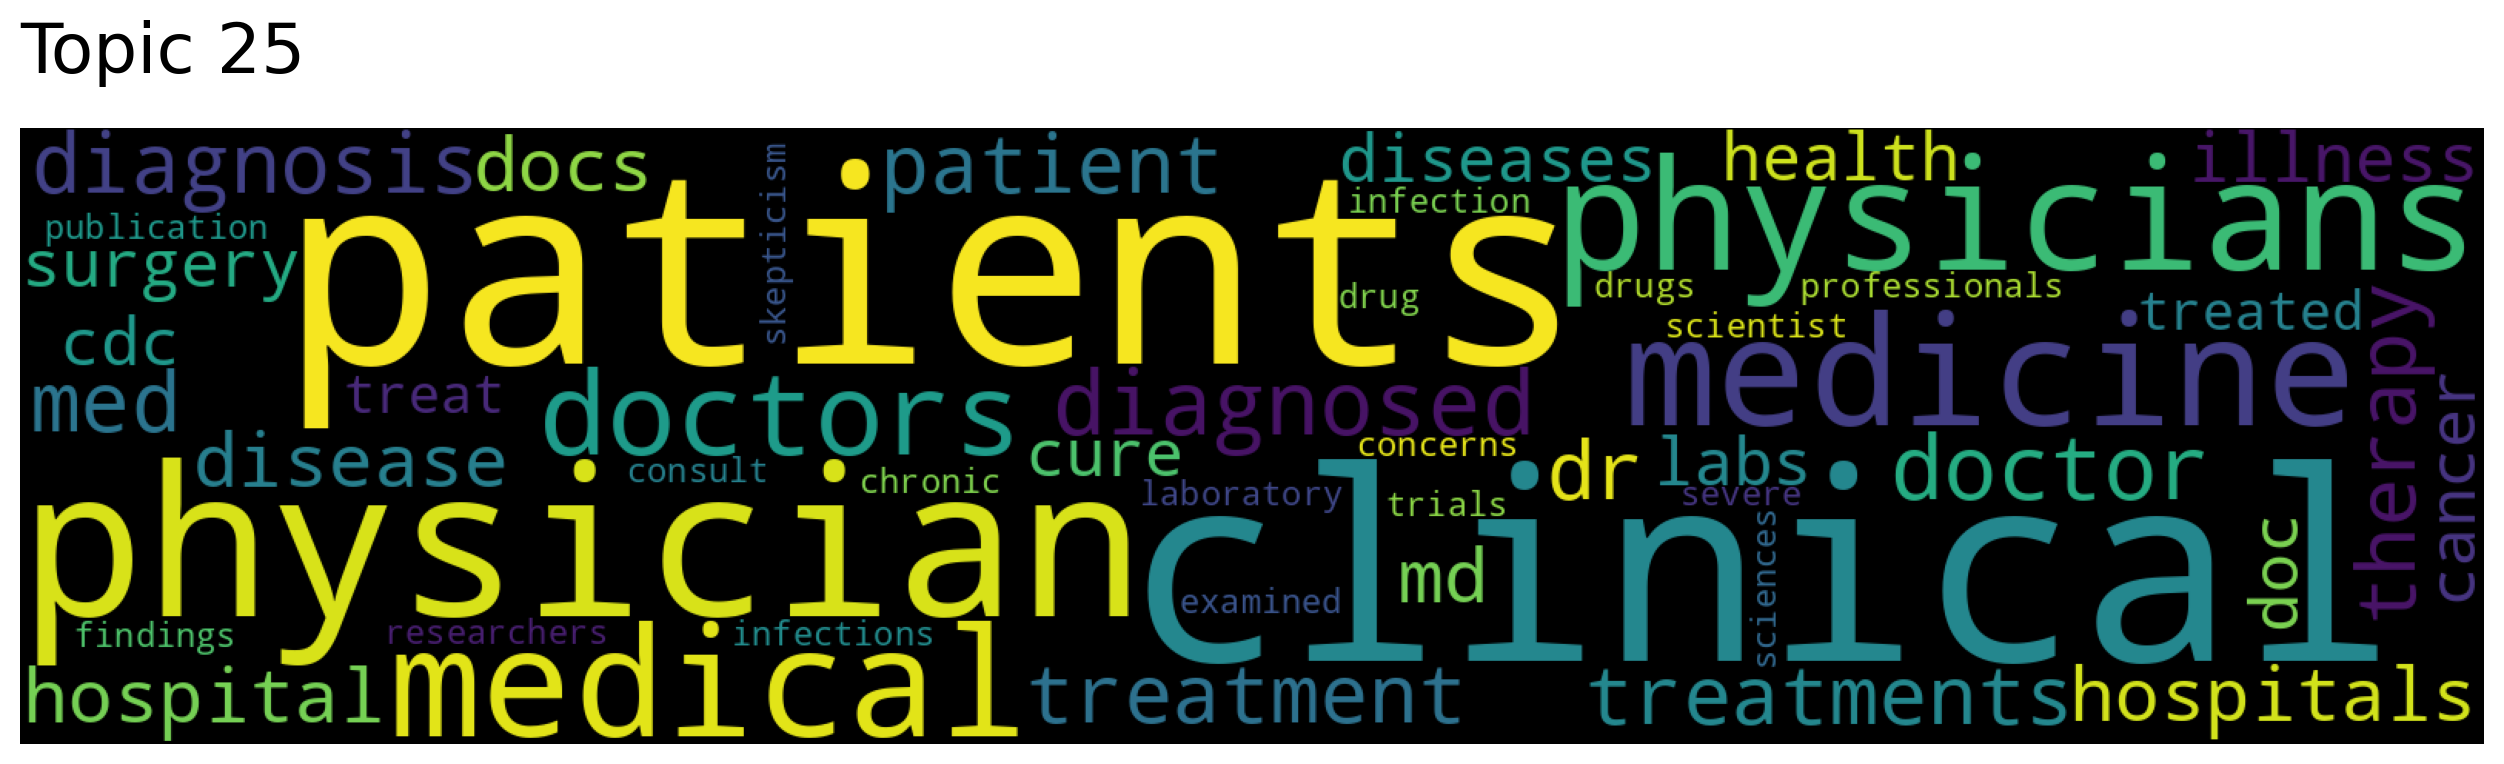

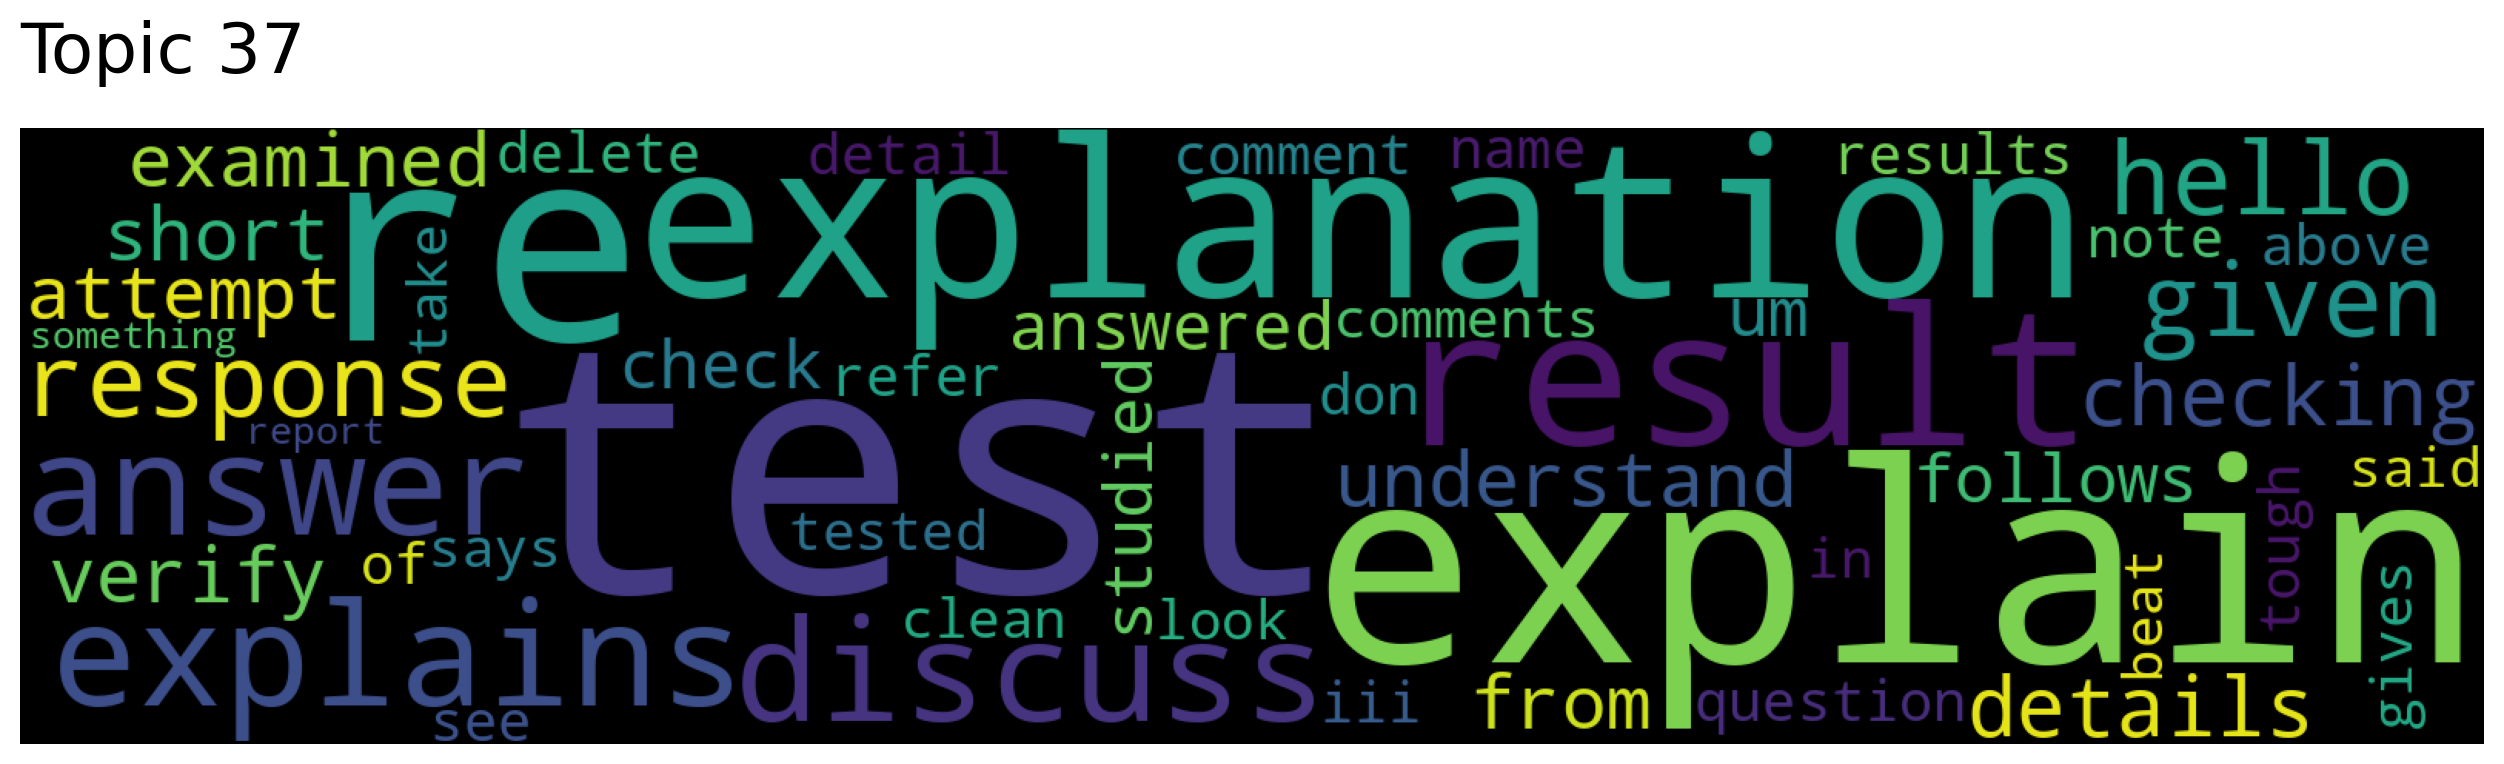

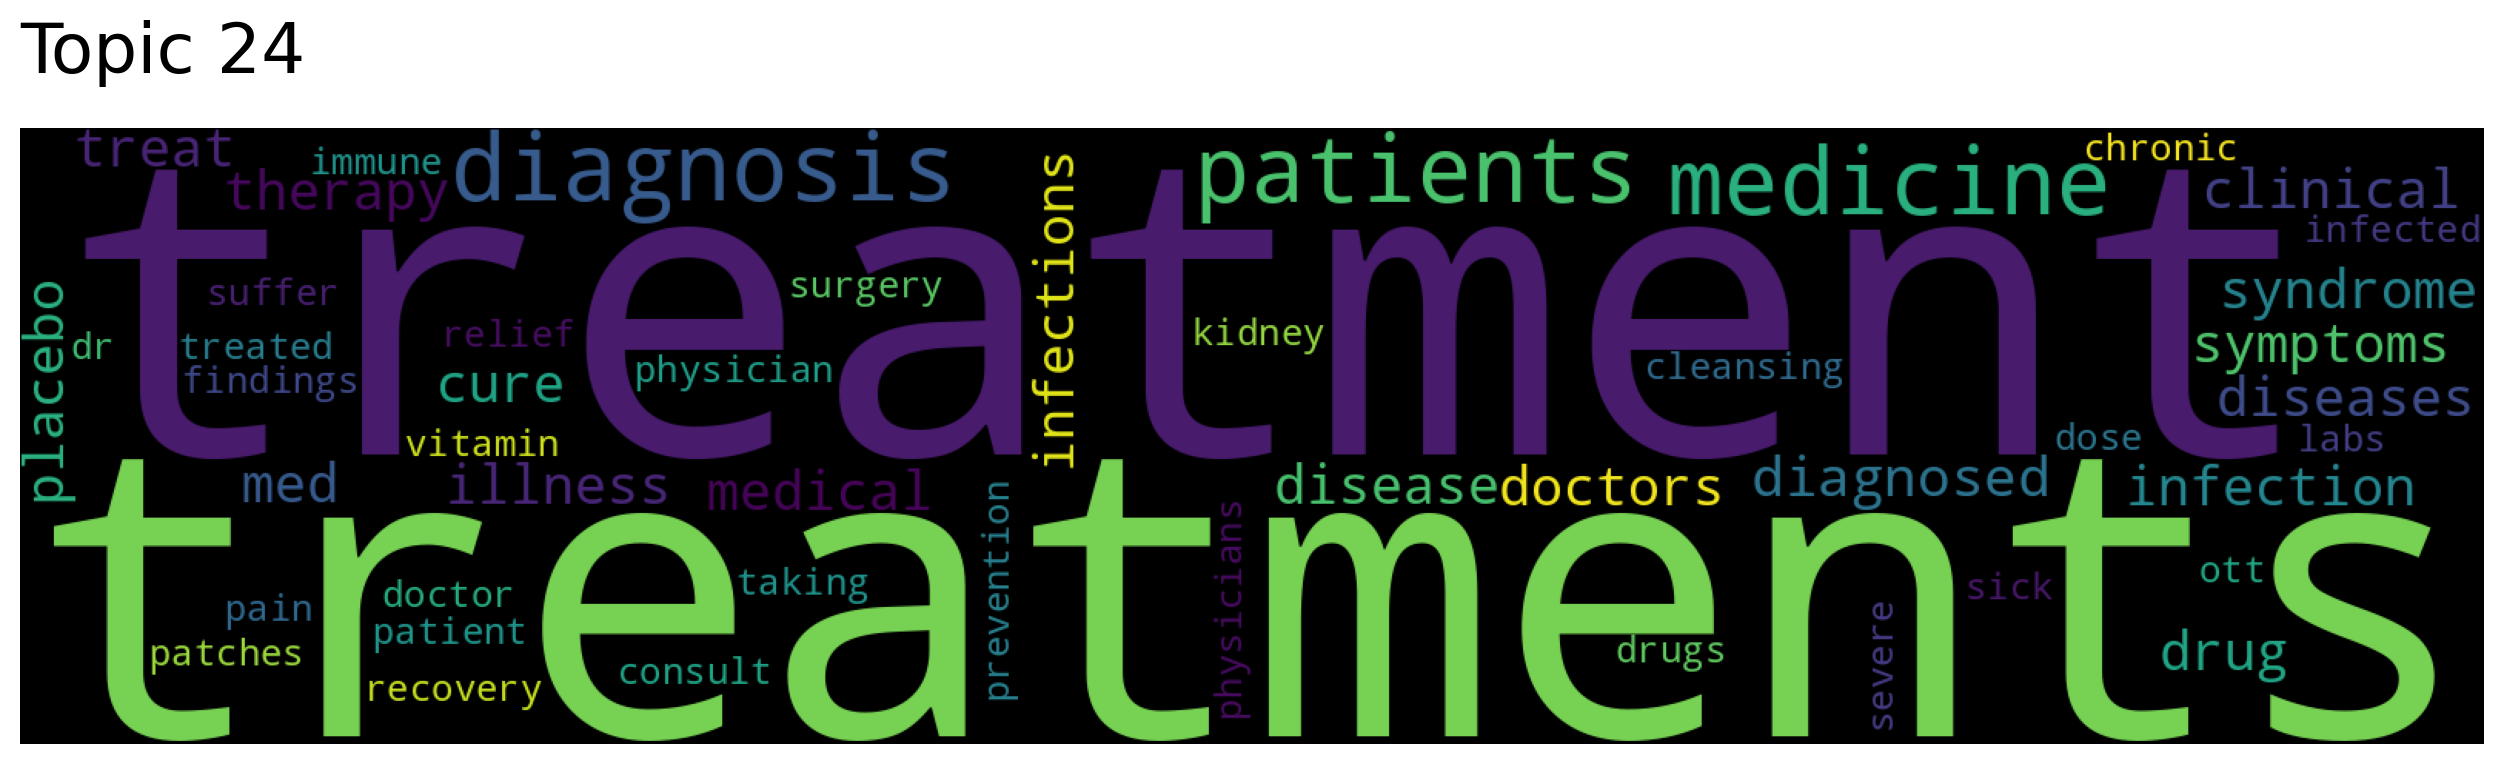

In [ ]:
for topic in topic_nums:
    model.generate_topic_wordcloud(topic)

Two of the three results are clearly medical: **Topic 25** (clinical practice: *patients, physicians, diagnosis, hospitals*) and **Topic 24** (*treatments, symptoms, therapy, placebo*). **Topic 37** is a "conversation" topic (*explain, answer, response, test*): words that appear in any discussion thread. Embedding-based topic models often produce a few generic topics like this, and it's worth spotting them before interpreting results.

## 4. Semantically similar words

Because words live in the same embedding space, we can find words close to *"phone"*:

In [ ]:
words, word_scores = model.similar_words(keywords=["phone"], keywords_neg=[], num_words=20)
for word, score in zip(words, word_scores):
    print(f"{word} {score}")

phones 0.8778208432959815
telephone 0.8053301911507009
calling 0.6541272901904274
calls 0.6455341355750793
motorola 0.6442875873842753
device 0.6204141206434977
dial 0.6089339191492724
computer 0.6022819154039083
call 0.5745551776017581
internet 0.5713799013438068
app 0.5652092297297151
galaxy 0.5508706027226331
car 0.5455411181326812
tel 0.545527465959315
apps 0.5447875576532267
talking 0.5366974140751116
tv 0.5321029315328951
apple 0.5307290765460537
devices 0.5307168314717584
television 0.5240784576072358


## 5. Semantic search over documents

Queries are embedded with the same model, so they can be **natural-language questions** rather than exact keywords:

In [ ]:
topic_words, word_scores, topic_scores, topic_nums = model.query_topics("Can you give me documents related to football?", num_topics=3)

In [ ]:
topic_nums

array([ 8, 65, 63])

In [ ]:
documents, doc_scores, doc_id = model.query_documents("do you know about football ", num_docs=3)
for i in documents:
  print(i)
  print("**************")

 

Well that's really great Pat.  I guess since you've played a little you thereby 
qualify as an expert.  Especially since you watch all the games on t.v.  All 
that qualifies you as is a armchair quarterback or a coach potato

Pat Walker
**************
There was an article in one of the U.K. dailies this week
about a soccer goalkeeper who had to be carried off the
field after a collision with a Ford Sierra cage.
**************


Ah, but the illusion in football is that there is always lots of action and
a sense of urgency because of the game clock (not all the time, but it happens
when there's less than 5 minutes to go quite often).  This sense creates
drama, even when there may not necessarily be any and that holds a viewer's
attention.  In baseball, only 3 players are involved in the action for about
(here comes a wild guess) 70% of the time?  And they're just playing a
sophisticated game of catch/hold-the-ball/step-out-of-the-box/adjust-chains/
touch-self-in-interesting-locations.

20 Newsgroups has no football group, only `rec.sport.baseball` and `rec.sport.hockey`. Yet the search still surfaced posts that genuinely discuss **football** and soccer, inside baseball threads. Matching works on **meaning**, not on category labels or exact keywords.

## 6. An interactive search app with Gradio

A minimal web UI around `query_documents`. Run it in Colab to get a temporary public link and search the collection from the browser.

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def query_documents(query):
  documents, doc_scores, doc_id = model.query_documents(query, num_docs=3)
  result_text = ""
  for i in documents:
    result_text += i + "\n**************\n"
  return result_text

iface = gr.Interface(fn=query_documents,
                     inputs=gr.Textbox(lines=2, placeholder="Enter your query here..."),
                     outputs="text",
                     title="Top2Vec Document Query",
                     description="Enter a query and get relevant documents from the 20 Newsgroups dataset.")

iface.launch(share=True)   # share=True gives a temporary public link from Colab


## Summary

| Capability | Method | Example |
|------------|--------|---------|
| Topic discovery | Embeddings → UMAP → HDBSCAN | 127 topics found automatically |
| Topic search | Nearest topic vectors to keywords | "medicine", "doctor" → clinical and treatment topics |
| Similar words | Nearest word vectors | "phone" → phones, telephone, calling, motorola |
| Semantic document search | Query embedding → nearest documents | "football" finds football posts with no football group |
| Web demo | Gradio | Interactive search UI |

**Compared with LDA**, the classic topic model, Top2Vec doesn't need the number of topics in advance, doesn't need stopword removal or lemmatization, and captures meaning through pretrained embeddings. The trade-off is less control and the occasional generic topic.